# Case Study: Converting casual riders into annual members by analysis of the Cyclistic Bike-Share program

**By : Paul Moses Ndosi**
 
**Introduction**<br>
In 2016, Cyclistic launched a successful bike-share offering in Chicago USA. Since then, the program has grown to a fleet of 5,824 bicycles that are geotracked and locked into a network of 692 stations across Chicago. The bikes can be unlocked from one station and returned to any other station in the system anytime. Until now, Cyclistic’s marketing strategy relied on building general awareness and appealing to broad consumer segments.

One approach that helped make these things possible was the flexibility of its pricing plans: single-ride passes, full-day passes, and annual memberships. Customers who purchase single-ride or full-day passes are referred to as casual riders. Customers who purchase annual memberships are Cyclistic members. Cyclistic’s finance analysts have concluded that annual members are much more profitable than casual riders. Although the pricing flexibility helps Cyclistic attract more customers, Cyclistics Marketing Director believes that maximizing the number of annual members will be key to future growth. Rather than creating a marketing campaign that targets all-new customers, the director of marketing believes there is a solid opportunity to convert casual riders into members and notes that casual riders are already aware of the Cyclistic program and have chosen Cyclistic for their mobility needs. The Marketing director has set a clear goal: Design marketing strategies aimed at converting casual riders into annual members.

In order to reaffirm to the director that maximizing the number of members by converting the casual riders to members is the right approach before developing a marketing campaign then by using the Cyclistic historical bike trip data to identify trends the following processes were undertaken

## **1.	Questions to be answered<br>**
* How do annual members and casual riders differ? 
* Why would casual members buy a membership?
* How can digital media be used to affect their marketing tactics. 

•	Primary Stakeholder: Lily Moreno (Director of Marketing)<br>
•	Secondary Stakeholders: Cyclistic Executive Team & Cylclistic marketing analytics team<br>
______________________________________________________________________________________________
## **2.	Data preparation** <br>
The ethical use of data and data privacy was taken into account by adhering to:<br>
  ROCCC Assessment:<br>
a.	Reliable & Original: Primary source data collected directly from Chicago’s Divvy bike-share system. <br>
b.	Comprehensive: Captures full 12-month trip logs including timestamps, station coordinates, and bike types.<br>
c.	Current & Cited: Public historical data licensed directly by Motivate.<br>

**Data Privacy & Limitations:**
a.	Riders' personally identifiable information (PII) is hidden under privacy restrictions.<br>
b.	Pass purchases cannot be tied to credit cards or residential ZIP codes to determine local vs. tourist ratios.<br>

**Data Loading and Initial Inspection** 

**Tool Chosen**: Python 3.0 (Pandas) on (colab note book) to handle high-volume data (>5.5 million rows).
- import pandas as pd
- import os 

**Loaded csv files**
Uploaded Divvy datasets (csv files)
q1_2019 = pd.read_csv("Divvy_Trips_2019_Q1.csv")
q1_2020 = pd.read_csv("Divvy_Trips_2020_Q1.csv")

**Output:** Loaded the Q1 2019 and Q1 2020 Divvy bike trip data into pandas DataFrames and performed an initial inspection of their structure and columns.
______________________________________________________________________________________________

## **3.Processing Data from Dirty to clean**
Compared column names for each of the files

print("Columns for Q1 2019:\n",q1_2019.columns)
print("\nColumns for Q1 2020:\n",q1_2020.columns)

**Output:**  Gave an output of all column names of Q1 2019 and Q1 2020
______________________________________________________________________________________________
Renamed Columns to make them look consistent with q1_2020

q1_2019 = q1_2019.rename(columns={'trip_id':'ride_id','bikeid':'rideable_type','start_time':'started_at','end_time':'ended_at','from_station_name':'start_station_name','from_station_id':'start_station_id','to_station_name':'end_station_name','to_station_id':'end_station_id','usertype':'member_casual'})

**Output:** Column harmonization: - Renamed columns in the 2019 dataset to align with the 2020 dataset, ensuring consistency (e.g., 'trip_id' to 'ride_id').
______________________________________________________________________________________________
Inspected the data and then looked for incongruities

print("\nQ1 2019 Data info:")
q1_2019.info()
print("\nQ1 2020 Data info:")
q1_2020.info()

**Output**: Column names, count and data types of Q1 2019 and Q2 2020 produced
______________________________________________________________________________________________
Converted ride_id and rideable_id to string so that they can stack correctly

q1_2019['ride_id'] = q1_2019['ride_id'].astype(str)
q1_2019['rideable_type'] = q1_2020['rideable_type'].astype(str)

**Output:Type Conversion**- Converted ride_id and rideable_type columns to string types to facilitate proper concatenation.
_____________________________________________________________________________________________
Stacked individual quater's data frames into one big data frame

all_trips=pd.concat([q1_2019,q1_2020],ignore_index=True)

**Output:Data Concatenation**- Merged the two quarterly datasets into a single DataFrame called all_trips.
____________________________________________________________________________________________
Removed lat,long, birthyear and gender fields as this data was droped beginning in 2020
The 'errors'='ignore' argument prevents an error if a column is not found

all_trips = all_trips.drop(['start_lat','start_lng','end_lat','end_lng','birthyear','gender'], axis=1, errors='ignore')

**Output:Irrelevant Column Removal**: Dropped columns that were either missing in one dataset or deemed not relevant for the current analysis (e.g., start_lat, end_lat, birthyear, gender).
______________________________________________________________________________________________
Inspected the new table that has been created

print("\nList of column names:\n",all_trips.columns)<br>
print("\nHow many rows are in data frame?",len(all_trips))<br>
print("\nDimensions of the data frame:",all_trips.shape)<br>
print("\nSee the first 6 rows of data frame:\n",all_trips.head())<br>
print("\nSee list of columns and data types:\n")
all_trips.info()<br>

|no.|Column|Non-null count|Dtype|
|---|---|---|---|
|0|ride_id|86929 non-null|object|
|1|started_at|86929 non-null|object|
|2|ended_at|86927non-null| object|
|3|rideable_type|37618 non-null|	object|
|4|	trip_duration|68119 non-null|object|
|5|	start_sation_id|86927 non-null|float64|
|6|	start_station_name|	86927 non-null|object|
|7|	end_station_id|86927 non-null|	Float64|
|8|	end_station_name|86927 non_null|object|
|9|	member_casual|86927 non-null|object|
			

Statistical summary of data(maily for numerics)
print("\nStatistical summary of data:\n",all_trips.describe())

Statistical summary of Data(all_trips)

|stat|start_station_id|end_station_id|
|---|---|---|
|count|86927.00000|86927.000000|
|mean|199.014495|199.121136|
|std|153.399865|154.81430|
|min|2.000000|2.000000|
______________________________________________________________________________________________
There are a few problems that needed to be fixed
* In the "member_casual" column there are two names for members("member" and "Subscriber") and two names for casual riders("Customer" and "casual"). They needed to be consolidated from four to two labels.
* In the "member_casual" column ,"Subscriber" is to be replaced with "member" and "customer" with "casual"Then observed how many observations fall under each user type

print("\n Value counts for 'member_casual'column before cleaning:\n", all_trips['member_casual'].value_counts())

**Output: Categorical Standardization**-  member_casual column consolidated 'Subscriber' and 'Customer' values have been replaced with 'member' and 'casual' respectively, handling potential whitespace issues.
_____________________________________________________________________________________________
Reassigned to the desired values (as per the current 2020 labels)

all_trips['member_casual'] = all_trips['member_casual'].astype(str).str.strip().replace({'Subscriber':'member','Customer':'casual'})

 **Output:** Value counts for ‘member_casual’ column before cleaning:
|member_casual|Count|
|---|---|
|Subscriber|64095|
|member|17834|
|Customer|4024|
|Casual|974|
Name: count, dtype:int64
______________________________________________________________________________________________
Checked to make sure the proper number of observations were reassigned
print("\n Value counts for 'member_casual' column after cleaning:\n", all_trips['member_casual'].value_counts())

**Output**: Value counts for member_casual column after cleaning
    |member_casual|Count|
    |---|---|
    |member| 81929|
    |casual| 4998|
    |nan|     2|
_____________________________________________________________________________________________
all_trips.dropna(subset=['started_at', 'ended_at'], inplace=True)
print(f"Number of rows after removing NaT values in 'started_at' or 'ended_at': {len(all_trips)}")

**Output:** Number of rows after removing Nat values in ‘started_at’ or ‘ended_at’ : 86927
_____________________________________________________________________________________________
Convert "started_at" and "ended_at" to datetime objects
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'], format='mixed')
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'], format='mixed')

**Output**: Datetime Conversion:-Converted started_at and ended_at columns to datetime objects for accurate temporal calculations.
_____________________________________________________________________________________________
The data can only be aggrevated at ride-level, which is too granular. Some additional columns of data are added -- such as day, month,year-- to provide additional opportunities to aggregate the data.

Added columns that list the date, month, day and year of each year
all_trips['started_at_date'] = all_trips['started_at'].dt.date
all_trips['started_at_month'] = all_trips['started_at'].dt.month
all_trips['day'] = all_trips['started_at'].dt.day
all_trips['year']=all_trips['started_at'].dt.year
all_trips['day_of_week']=all_trips['started_at'].dt.day_name()

**Output**: Date-related columns added- New columns like started_at_date, started_at_month, day, year, and day_of_week have been extracted from the started_at column.
______________________________________________________________________________________________
A calculated field for length of ride added since 2020Q1 data did not have the "tripduration" column. the ride_length is added to the entire data frame to ensure consistency
Added a "ride_length" calculation to all_trips (in seconds)
all_trips['ride_length']=(all_trips['ended_at']-all_trips['started_at']).dt.total_seconds()

**Output:** ride_length calculated- A ride_length column (in seconds) has been added to the DataFrame, calculating the duration of each ride.
Ride Length Calculation: Calculated by subtracting started_at from ended_at.
___________________________________________________________________________________________
Inspected the structure of the columns
print("\nData types after adding the date columns and ride_length:\n")
all_trips.info()



|no.|Column	|Non_Null Count|Dtype|
|---|---|---|---|
|0	|ride_id|	86927 non-null|	object|
|1	|started_at	|86927 non-null	|datetime64[ns]|
|2 |ended_at	|86927 non-null|	datetime64[ns]|
|3|	rideable_type|	37617 non-null|	object|
|4	|tripduration|	68119 non-null|	object|
|5|	start_station_id|	86927 non-null|	float64|
|6|	start_station_name|	86927 non-null|	object|
|7|	end_station_id|	86927 non-null|	float64|
|8|	end_station_name |86927 non-null|	object|
|9|	member_casual|	86927 non-null|	object|
|10|	started_at_date|	86927 non-null|	object|
|11	|started_at_month|	86927 non-null|	Int32|
|12|	day|	86927 non-null	|Int32|
|13	|year|	86927 |non-null	|Int32|
|14|	day_of week|	86927| non-null|	object|
|15|	ride_length|	86927 non-null|	float64|

____________________________________________________________________________________________
Removed "bad" data There are some rides where the tripduration shows up as negative including several hundred rides where Divvy took bikes out of circulation for Quality Control reasons. These rides were deleted.

Created a new version of the data frame (v2) since data is being removed
all_trips_v2=all_trips[(all_trips['start_station_name']!="HQ QR") & (all_trips['ride_length']>=0)].copy()

**Output**: 'Bad' data removed: rides with non-positive ride_length and those originating from 'HQ QR' stations have been filtered out, creating all_trips_v2.
_____________________________________________________________________________________________

## **4.DESCRIPTIVE ANALYSIS**

Desriptive analysis on ride_length (all figures in seconds)
print("\nDescriptive statistics for ride_length:\n",all_trips_v2['ride_length'].describe())

**Output**: Performed descriptive statistical analysis on the ride_length column.

|Count|8.692700e+04|
|---|---|
|Mean |  9.394577e+02|
|Std |    1.530110e+04|
|Min|       2.00000e+04|
|25% |     3.250000e+02|
|50% |     5.180000e+02|
|75% |     8.520000+02|
|Max |     3.711293e+06|

Name: ride_length, dtype: float64
_____________________________________________________________________________________________
Compared members and casual users
print("\n Ride length statistics grouped by member_casual:\n",
      all_trips_v2.groupby('member_casual')['ride_length'].agg(['mean','median','max','min']))

**Output**: Compared key ride length statistics (mean, median, max, min) between 'member' and 'casual' riders.
_____________________________________________________________________________________________
Ride length statistics grouped by member_casual:

|member_casual|	mean|	median|	max|	min|
|---|---|---|---|---|
|casual|	3853.465786|	1307.0	|3711293.0|	2.0|
|member	|761.69142|	499.0|	1231182.0|	2.0|

See the average ride time for each day members vs casual users
print("\nAverage ride length by member type and day of the week:\n",
      all_trips_v2.groupby(['member_casual','day_of_week'])['ride_length'].mean())

**Output:** Aggregated data to find the average ride length by rider type and day of the week.
______________________________________________________________________________________________
Ordered the days of the week for correct sorting for analysis
days_order=["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
all_trips_v2['day_of_week']=pd.Categorical(all_trips_v2['day_of_week'],categories=days_order,ordered=True)

**Output**: Categorical Ordering- Ordered the day_of_week column to ensure correct chronological sorting for future analysis and visualizations.
_____________________________________________________________________________________________
Ran the aggregation again to see the sorted result
print("\nAverage ride length(sorted by day of week):\n",all_trips_v2.groupby(['member_casual','day_of_week'])['ride_length'].mean())

**Output:** Results of average_ride_length sortedby day_of_week
______________________________________________________________________________________________
Analyzed ridership data by type and weekday
summary_stats=all_trips_v2.groupby(['member_casual','day_of_week']).agg(
    number_of_rides=('ride_id','count'),
    average_duration=('ride_length','mean')).reset_index()

**Output**: Created variables

print("\nSummary of rides and duration by the rider type and weekday\n",summary_stats)

**Output**: Generated a summary_stats table showing the number of rides and average duration for each rider type and day of the week.

counts=all_trips_v2.groupby(['member_casual','day_of_week'])['ride_length'].mean().reset_index()
counts = counts[counts['member_casual'] != 'nan']
counts.to_csv('avg_ride_length.csv',index=False)
Output: Variables created


## 5.DATA VISUALIZATION


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='ride_length', hue='member_casual', data=counts, palette='viridis')
plt.title('Average Ride Length by Rider Type and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Ride Length (seconds)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()

**Data Visualization Graph 1**: Generated and displayed a bar chart that visually compares the average ride length between 'member' and 'casual' riders across different days of the week.

#Graph 1
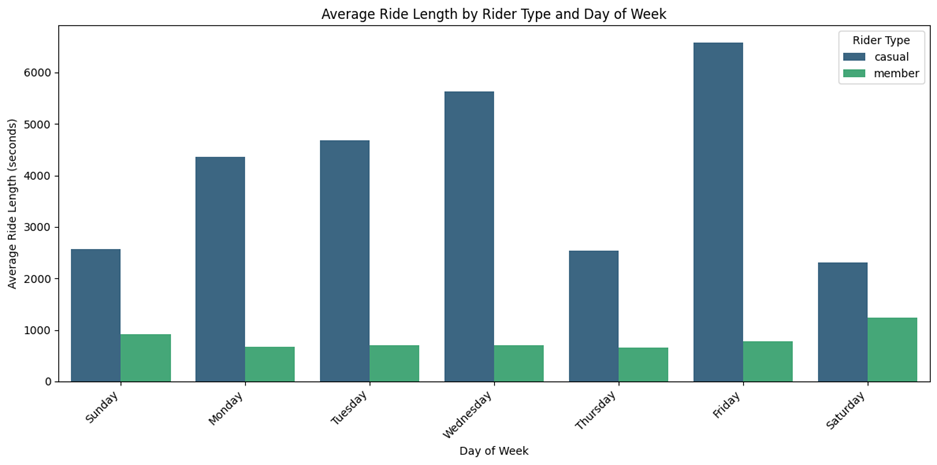

import matplotlib.pyplot as plt
import seaborn as sns

****Filter out 'nan' from member_casual before plotting
summary_stats_filtered = summary_stats[summary_stats['member_casual'] != 'nan']

plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='number_of_rides', hue='member_casual', data=summary_stats_filtered, palette='viridis')
plt.title('Number of Rides by Rider Type and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()



**Data Visualization Graph 2:** Generated and displayed a bar chart that visually compares the number of rides between 'member' and 'casual' riders across different days of the week.

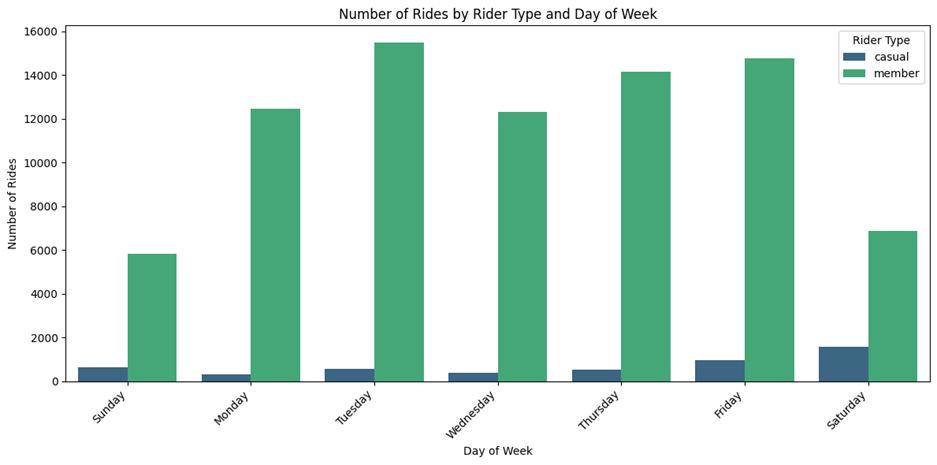

## 6.Sharing information to Key Stakeholders

Comparing the two graphs reveals distinct usage patterns between casual and member riders. Here's an analysis and some recommendations:

### Key Observations on Average Ride Duration (Graph 1):<br>

To answer the question **“How do annual members and casual riders differ?”<**br> 
**Member Riders**: Consistent and Shorter Durations: Members exhibit relatively consistent and shorter average ride durations throughout the week. Their average ride length generally hovers around 600-900 seconds (10-15 minutes), peaking slightly on Saturdays (around 1230 seconds) and Sundays (around 910 seconds). This pattern reinforces the idea that members primarily use the service for predictable, routine, and often shorter trips.<br>

**Casual Riders:** Significantly Longer and More Variable Durations: Casual riders consistently take much longer rides on average compared to members. Their average ride durations are also more variable across the week.<br>

**Leisure and Exploration:** The extended ride lengths, particularly on Fridays, Wednesdays, and Tuesdays, strongly suggest that casual riders use the service for leisure, recreational activities, or exploring, rather than quick commutes. Weekends (Saturday and Sunday) also show substantial average ride times, supporting this hypothesis.br

### Key observations on Number of Rides by Rider Type and Day of Week (Graph 2)<br>
****Member Riders:** Member **riders consistently show a much higher number of rides throughout the week compared to casual riders. Their peak usage occurs on weekdays, especially Tuesday, Monday, Thursday, and Friday. This suggests that members primarily use the bike-sharing service for commuting or daily routine activities. Their weekend usage is lower but still significant.<br>
**Casual Riders**: Casual riders, while having a significantly lower total number of rides, exhibit a clear preference for weekend usage. Their highest number of rides is observed on Saturday, followed by Friday and Sunday. This pattern indicates that casual users are more likely to use the service for recreational purposes or leisure activities, particularly during their time off.<br>

•	To answer the question “**Why would casual members buy a membership?**”<br>
**Casual Riders:** Lower Frequency, Longer Rides: Casual riders take fewer rides overall but exhibit substantially longer average ride durations, particularly on weekends and some weekdays. Their usage spikes on weekends (especially Saturday), with notable activity on Friday, pointing towards recreational or leisure-oriented use cases. There's a significant weekend leisure market for casual riders<br>

**Opportunities for Conversion & Engagement by Marketing Management**
****Long Casual Rides**: **The extended ride lengths observed among casual users present a clear opportunity for membership conversion. By highlighting the cost-effectiveness of membership for longer trips, the service can incentivize casual users to become members.<br>
**Weekday Casual Usage:** Casual riders taking long trips on weekdays (e.g., Wednesday, Friday) could represent specific tourist segments or unique use cases that could be targeted with tailored offers or partnerships.
## Recommendations:
•	To answer the question **“How can digital media be used to affect their marketing tactics?”**<br> 
**Targeted Membership Promotions:** Develop campaigns specifically aimed at casual riders who take longer, more frequent trips, emphasizing the value proposition of membership (e.g., cost savings for extended use, unlimited rides).

**Enhance Weekend Offerings:** Explore partnerships or promotions with local attractions and leisure venues to further capitalize on the casual riders' weekend usage patterns.

**Customer Feedback & Segmentation:** Conduct further research (e.g., surveys, interviews) to understand the motivations behind casual riders' long weekday trips to uncover new market segments or service improvements.



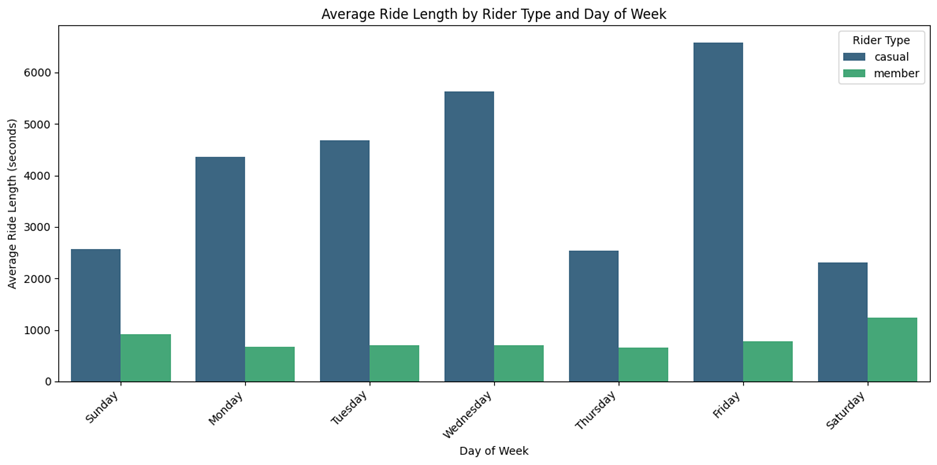
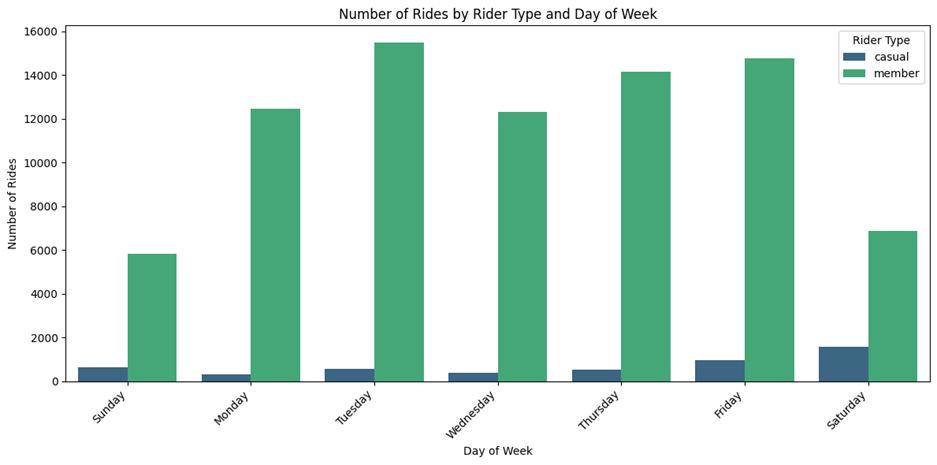
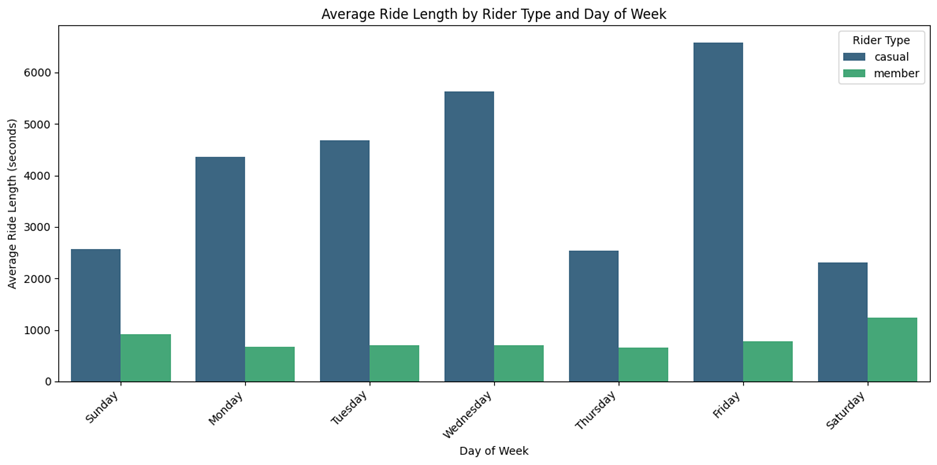
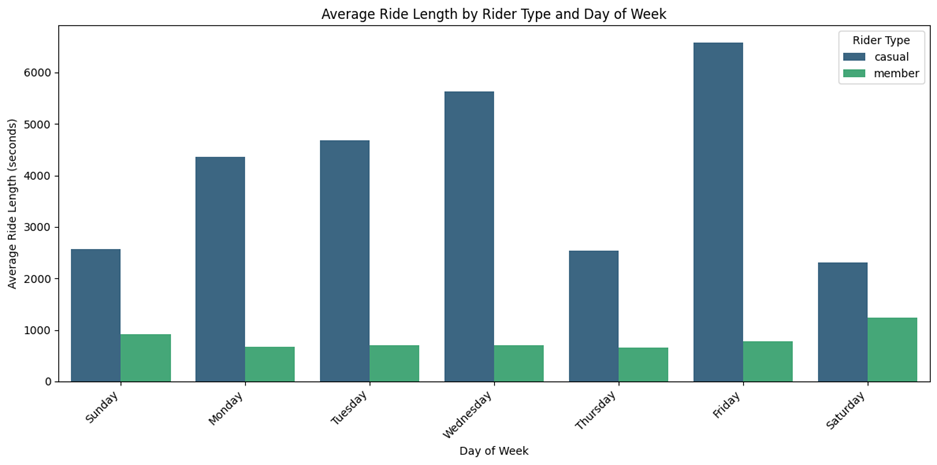
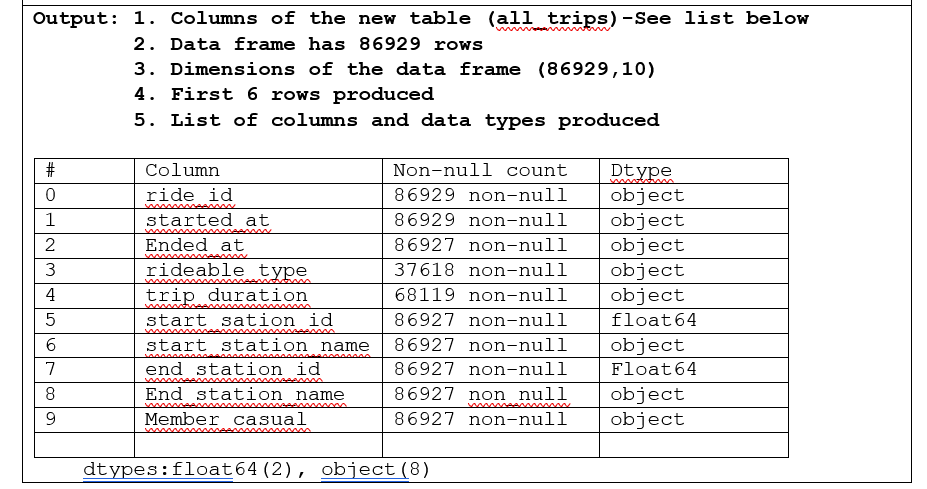
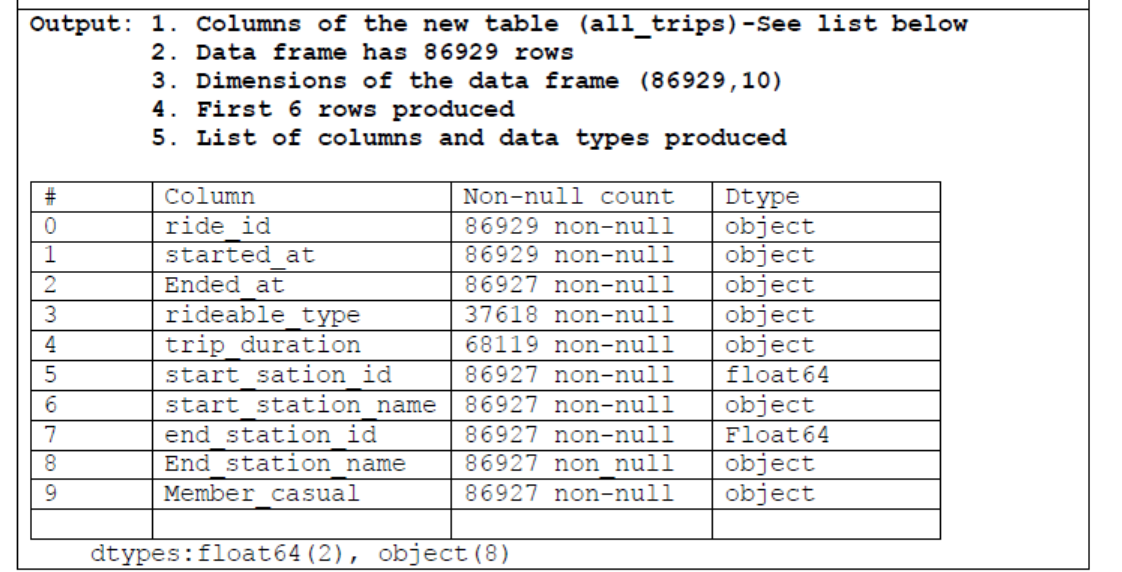
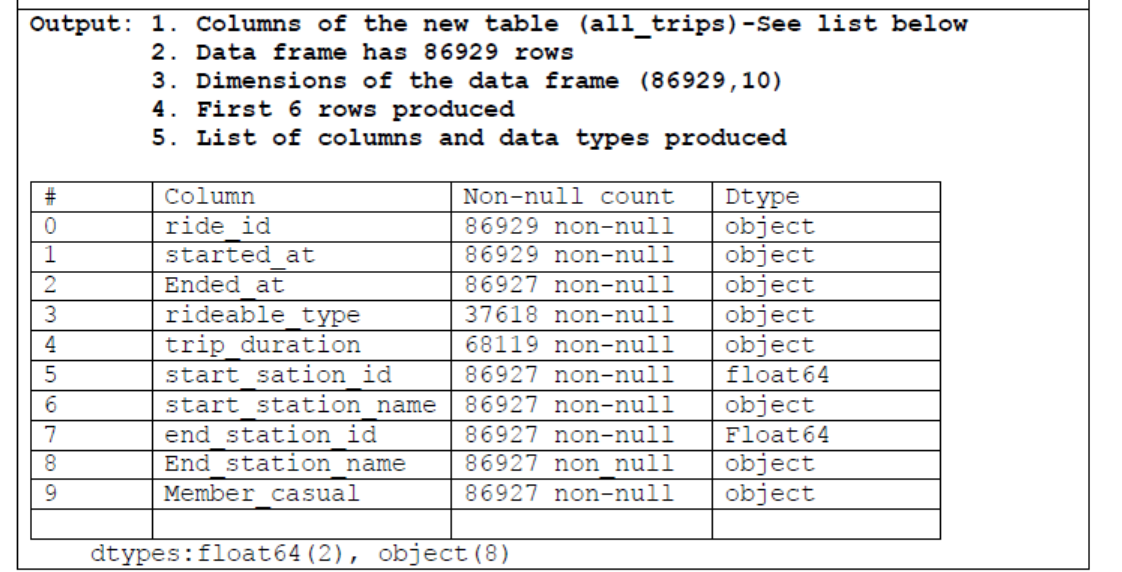
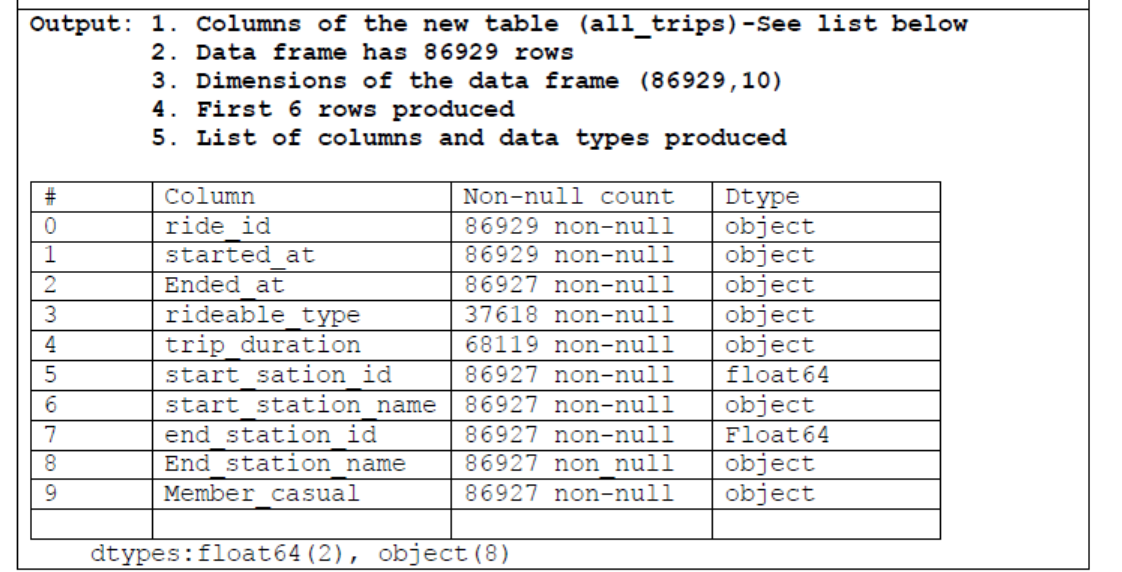
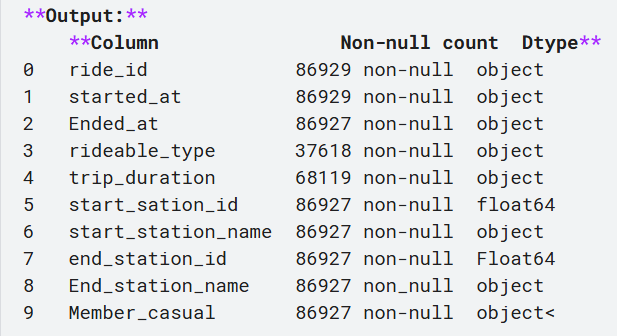